 ## Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import  train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import  KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import  LGBMClassifier

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

## 1.Load and explore data

In [2]:
# Load data
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

print("Train shape:", train_df.shape)
print("Test shape:",  test_df.shape)
print("\nTrain info:")
train_df.info()
print(f"\nFirst few rows:")


Train shape: (891, 12)
Test shape: (418, 11)

Train info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

First few rows:


In [4]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Exploratory Analysis (EDA)

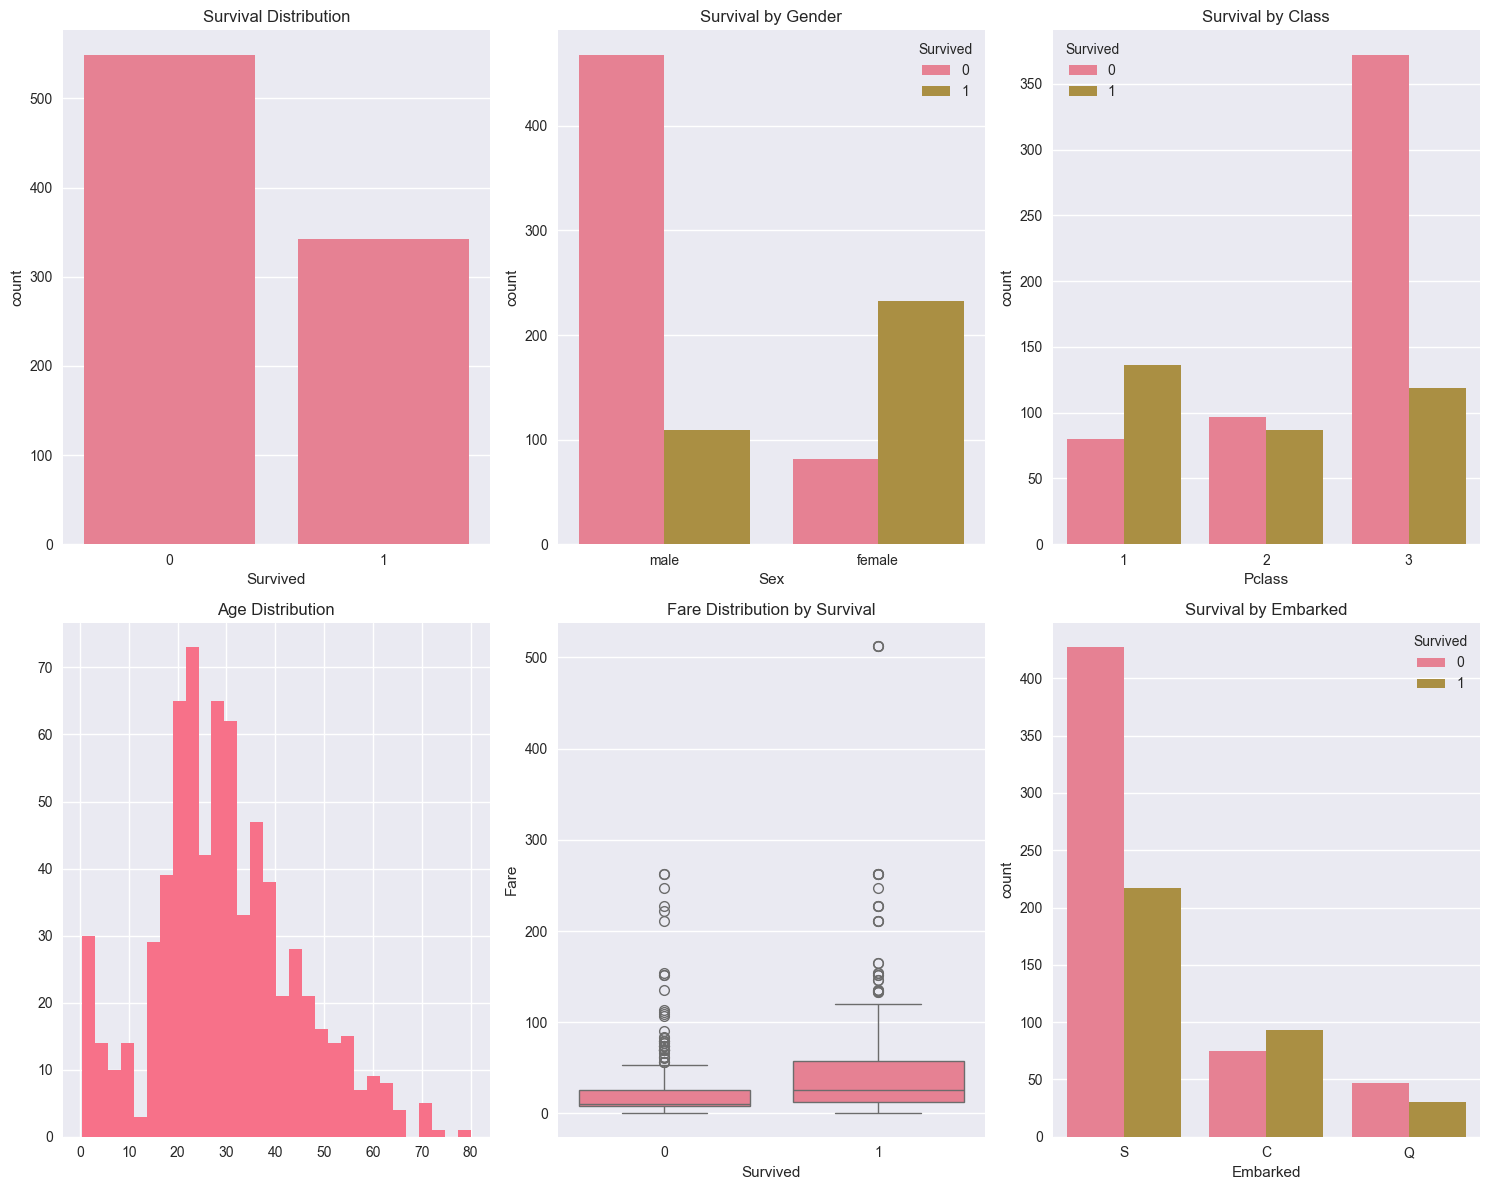

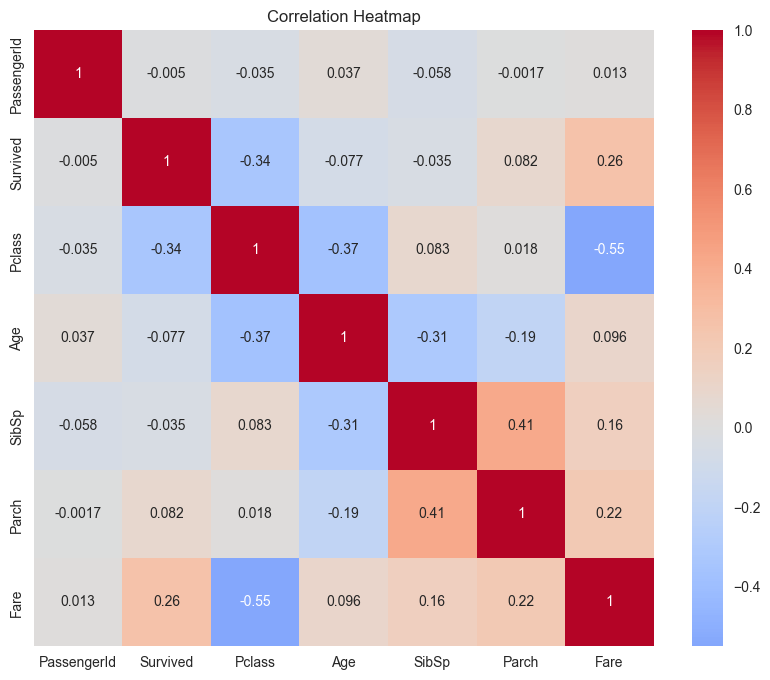

In [5]:
# Basic EDA
plt.figure(figsize=(15, 12))

plt.subplot(2, 3, 1)
sns.countplot(data=train_df, x='Survived')
plt.title('Survival Distribution')

plt.subplot(2, 3, 2)
sns.countplot(data=train_df, x='Sex', hue='Survived')
plt.title('Survival by Gender')

plt.subplot(2, 3, 3)
sns.countplot(data=train_df, x='Pclass', hue='Survived')
plt.title('Survival by Class')

plt.subplot(2, 3, 4)
train_df['Age'].hist(bins=30)
plt.title('Age Distribution')

plt.subplot(2, 3, 5)
sns.boxplot(data=train_df, x='Survived', y='Fare')
plt.title('Fare Distribution by Survival')

plt.subplot(2, 3, 6)
sns.countplot(data=train_df, x='Embarked', hue='Survived')
plt.title('Survival by Embarked')

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
numeric_cols = train_df.select_dtypes(include=[np.number]).columns # for selecting numeric columns
sns.heatmap(train_df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0) #dbt
plt.title('Correlation Heatmap')
plt.show()